In [1]:
import os
from datetime import datetime
from typing import Dict, Union
import pickle
import pandas as pd
import torch
from azureml.core import Workspace, Dataset, Datastore

In [2]:
EXPOSURE_PATH = "p1_postop/SSL/exposure/preop.csv"
OUTCOME_PATH = "p1_postop/SSL/targets/PRI.csv"
MAPPING_PATH = "Zahra/FINAL/PreMEDS_MDPS/hash_to_integer_map.pkl"
DATASTORE_NAME = "researcher_data"

# Azure ML workspace configuration
SUBSCRIPTION_ID = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
RESOURCE_GROUP = 'forskerpl-n0ybkr-rg'
WORKSPACE_NAME = 'forskerpl-n0ybkr-mlw'

TIMESTAMP_COL = 'time'
ABSPOS_COL = 'abspos'
PID_COL = 'subject_id'
MANDATORY_COLUMNS = [TIMESTAMP_COL, PID_COL]


In [3]:
def get_workspace() -> Workspace:
    return Workspace(
        subscription_id=SUBSCRIPTION_ID,
        resource_group=RESOURCE_GROUP,
        workspace_name=WORKSPACE_NAME
    )

# -------------------
# Load CSV from Datastore
# -------------------
def read_csv_from_datastore(
    ws: Workspace,
    datastore_name: str,
    csv_path: str,
    rename_dict: Dict[str, str] = None,
    local_dir: str = "./temp_data"
) -> pd.DataFrame:
    os.makedirs(local_dir, exist_ok=True)
    datastore = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((datastore, csv_path))
    file_paths = dataset.download(target_path=local_dir, overwrite=True)
    df = pd.read_csv(file_paths[0])
    if rename_dict:
        df = df.rename(columns=rename_dict)
    return df


# -------------------
# Load PyTorch Mapping File from Datastore
# -------------------

def load_mapping_from_datastore_file(
    ws: Workspace,
    datastore_name: str,
    file_path: str,
    local_dir: str = "./temp_data"
) -> Dict[str, int]:
    os.makedirs(local_dir, exist_ok=True)
    datastore = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((datastore, file_path))
    downloaded_files = dataset.download(target_path=local_dir, overwrite=True)
    
    local_path = downloaded_files[0]
            
    with open(local_path, "rb") as f:
        mapping = pickle.load(f)
    
    return mapping
# -------------------
# Data Cleaning Utilities
# -------------------
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    if all(col in df.columns for col in MANDATORY_COLUMNS):
        df = df.dropna(subset=MANDATORY_COLUMNS, how="any")
    df = df.drop_duplicates()
    return df


def get_hours_since_epoch(timestamps: Union[pd.Series, datetime]) -> Union[pd.Series, float]:
    if isinstance(timestamps, pd.Series):
        if len(timestamps) == 0:
            return pd.Series([], dtype=float)
        timestamps = pd.to_datetime(timestamps, utc=True, errors="coerce").dt.tz_localize(None)
        seconds = timestamps.view("int64") // 10**9  # ✅ بدون اخطار در پانداس جدید
        hours = seconds / 3600
        return hours
    else:
        ts = pd.to_datetime(timestamps, utc=True).tz_localize(None)
        return (ts.value // 10**9) / 3600

def map_pids_to_ints(df: pd.DataFrame, pid_map: Dict[str, int]) -> pd.DataFrame:
    df[PID_COL] = df[PID_COL].astype(str).map(pid_map)
    df = df.dropna(subset=[PID_COL])
    df = df.copy()
    #df.loc[:, PID_COL] = df[PID_COL].astype(int)
    df[PID_COL] = df[PID_COL].astype(int)
    return df


In [4]:
if __name__ == "__main__":
    ws = get_workspace()

# -------------------
# Reading Data
# -------------------
    exposure = read_csv_from_datastore(
        ws,
        datastore_name=DATASTORE_NAME,
        csv_path=EXPOSURE_PATH,
        rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
    )

    outcome = read_csv_from_datastore(
        ws,
        datastore_name=DATASTORE_NAME,
        csv_path=OUTCOME_PATH,
        rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
    )
# -------------------
# Clean Data
# -------------------
    exposure = clean_data(exposure)
    outcome = clean_data(outcome)

    print(" Raw exposure TIMESTAMP samples:")
    print(exposure.head(10))
    print(exposure.dtypes)

    print("\n Raw outcome TIMESTAMP samples:")
    print(outcome[TIMESTAMP_COL].head(10))
    print(outcome.dtypes)
# -------------------
# Load Mapping file
# -------------------
    pid_map = load_mapping_from_datastore_file(
        ws,
        datastore_name=DATASTORE_NAME,
        file_path=MAPPING_PATH
    )
# -------------------
# Map pids to ints
# -------------------
    exposure = map_pids_to_ints(exposure, pid_map)
    outcome = map_pids_to_ints(outcome, pid_map)
# -------------------
# Change Abspos col
# -------------------
    exposure[ABSPOS_COL] = get_hours_since_epoch(exposure[TIMESTAMP_COL]).astype(int)
    outcome[ABSPOS_COL] = get_hours_since_epoch(outcome[TIMESTAMP_COL]).astype(int)

    print("Exposure sample:")
    print(exposure.head())

    print("Outcome PRI sample:")
    print(outcome.head())

Timeout was exceeded in force_flush().
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
 Raw exposure TIMESTAMP samples:
                                          subject_id        time  abspos
0  88572797278B2604219A1962B005B801289909140F1CA7...  2016-05-24  -32208
1  A34E5948E6C23BDED4FCD553D0BC34649EE22759D15454...  2016-06-22  -31512
2  E8B62CFB71809D901D1F101BFE66F5EB2DD1718227E698...  2016-11-05  -28248
3  F3046580D734B72A9297A8D2F78D0C32DEFB51ED1B71E0...  2016-11-05  -28248
4  E11AAAD876434636E91090720629285F45E1F3988CA7AB...  2016-11-07  -28200
5  B8D182E9A64ABD5B53218D83FB5

In [8]:
import pandas as pd

# Assume: df_exposure and df_outcome are already read from files
# df_exposure = pd.read_csv("exposure.csv")
# df_outcome = pd.read_csv("outcome.csv")

# Convert time columns to datetime
exposure["time"] = pd.to_datetime(exposure["time"])
outcome["time"] = pd.to_datetime(outcome["time"])

# Get the earliest exposure time for each subject
exposure_min = exposure.groupby("subject_id")["time"].min().reset_index()
exposure_min = exposure_min.rename(columns={"time": "exposure_time"})

# Join outcomes with the earliest exposure time
merged = pd.merge(outcome, exposure_min, on="subject_id", how="inner")

# Calculate the difference in days between outcome and exposure
merged["delta_days"] = (merged["time"] - merged["exposure_time"]).dt.days

# Find subjects where any outcome happened before exposure
invalid_subjects = merged.loc[merged["delta_days"] < 0, "subject_id"].unique()

if len(invalid_subjects) == 0:
    print("All outcomes occur after exposure.")
else:
    print(f" {len(invalid_subjects)} subjects have outcomes before exposure:")
    print(invalid_subjects)


All outcomes occur after exposure.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assume exposure has: subject_id, time, abspos
exp = exposure.copy()

# --- dtypes ---
exp["time"] = pd.to_datetime(exp["time"], errors="coerce")

# (optional) de-dup exact duplicates per subject/time or subject/abspos
exp = exp.drop_duplicates(subset=["subject_id", "abspos"])

Subjects with exactly 1 exposure: 372551
Subjects with >1 exposure: 153454

Distribution of n_exposures (top 10 rows):
1     372551
2     103155
3      31160
4      10901
5       4259
6       1845
7        926
8        465
9        281
10       164
Name: n_exposures, dtype: int64


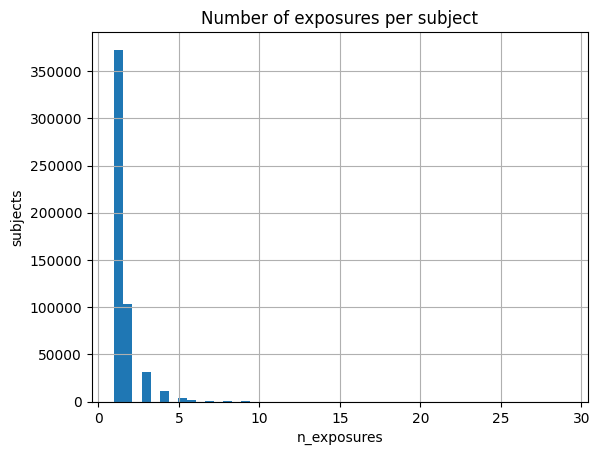

In [6]:
# =========================
# 1) How many exposures per subject?
# =========================
counts = exp.groupby("subject_id").size().rename("n_exposures")
print("Subjects with exactly 1 exposure:", (counts == 1).sum())
print("Subjects with >1 exposure:", (counts > 1).sum())

print("\nDistribution of n_exposures (top 10 rows):")
print(counts.value_counts().sort_index().head(10))

# Histogram of exposure counts
counts.hist(bins=50)
plt.title("Number of exposures per subject")
plt.xlabel("n_exposures")
plt.ylabel("subjects")
plt.show()


In [11]:
import pandas as pd

# exposure: subject_id, time, abspos
total_subjects = exposure["subject_id"].nunique()
total_exposures = len(exposure)

# اگر فقط اولین exposure هر بیمار رو نگه داریم:
kept_exposures = total_subjects
dropped_exposures = total_exposures - kept_exposures
pct_dropped_exposures = 100 * dropped_exposures / total_exposures

print("Total subjects:", total_subjects)
print("Total exposures:", total_exposures)
print("Dropped exposures (keep-first):", dropped_exposures)
print(f"% exposures dropped: {pct_dropped_exposures:.2f}%")


Total subjects: 526005
Total exposures: 766764
Dropped exposures (keep-first): 240759
% exposures dropped: 31.40%


In [15]:
task_name = "PRI Prediction"
PID_COL="subject_id"
n_exp = len(exposure)
n_exp_pat = exposure[PID_COL].nunique()

n_out = len(outcome)
n_out_pat = outcome[PID_COL].nunique()

pos_rate = outcome[PID_COL].mean()   # چون 0/1 است

print(f"Task: {task_name}")
print(f"   - Exposure: {n_exp:,} records, {n_exp_pat:,} patients")
print(f"   - Outcome:  {n_out:,} records, {n_out_pat:,} patients")
print(f"   - Positive rate: {n_out/n_exp:.2%}")


Task: PRI Prediction
   - Exposure: 766,764 records, 526,005 patients
   - Outcome:  1,813 records, 1,788 patients
   - Positive rate: 0.24%


In [16]:
exposure.to_csv("./temp_data/exposure_PRI.csv", index=False)
outcome.to_csv("./temp_data/outcome_PRI.csv", index=False)


Gaps (hours) — describe:
count    240759.000000
mean       9526.268675
std        8780.410994
min         720.000000
10%        1368.000000
25%        2856.000000
50%        6480.000000
75%       13584.000000
90%       22680.000000
95%       28248.000000
99%       37512.000000
max       50928.000000
Name: gap_hours, dtype: float64

Gaps (days) — describe:
count    240759.000000
mean        396.927861
std         365.850458
min          30.000000
10%          57.000000
25%         119.000000
50%         270.000000
75%         566.000000
90%         945.000000
95%        1177.000000
99%        1563.000000
max        2122.000000
Name: gap_hours, dtype: float64

Zero-gap exposures: 0
Negative-gap exposures: 0


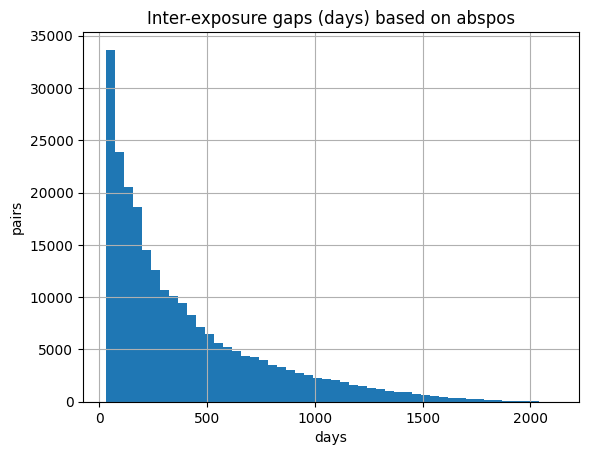

In [14]:

exp_sorted = exp.sort_values(["subject_id", "abspos"]).copy()
exp_sorted["gap_hours"] = exp_sorted.groupby("subject_id")["abspos"].diff()  # hours between consecutive exposures
gaps = exp_sorted.loc[exp_sorted["gap_hours"].notna(), "gap_hours"]

# Basic stats
print("\nGaps (hours) — describe:")
print(gaps.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]))

# In days
gaps_days = gaps / 24.0
print("\nGaps (days) — describe:")
print(gaps_days.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]))

# Negative/zero checks (should not happen if sorted + unique)
print("\nZero-gap exposures:", (gaps == 0).sum())
print("Negative-gap exposures:", (gaps < 0).sum())

# Histogram of gaps
gaps_days.hist(bins=50)
plt.title("Inter-exposure gaps (days) based on abspos")
plt.xlabel("days")
plt.ylabel("pairs")
plt.show()


In [17]:
from azureml.core import Workspace, Datastore
from azure.storage.filedatalake import DataLakeServiceClient
from azure.identity import DefaultAzureCredential
import os

# تنظیمات Azure ML workspace
subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'

# اتصال به workspace
ws = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(ws, "researcher_data")

# استخراج اطلاعات واقعی از datastore
account_name = datastore.account_name
filesystem_name = datastore.container_name
credential = DefaultAzureCredential()

def upload_to_adls2(account_name, filesystem_name, directory_path, local_file_path, remote_file_name, credential):
    service_client = DataLakeServiceClient(account_url=f"https://{account_name}.dfs.core.windows.net", credential=credential)
    file_system_client = service_client.get_file_system_client(file_system=filesystem_name)
    directory_client = file_system_client.get_directory_client(directory_path)

    print("Uploading file")

    file_client = directory_client.create_file(remote_file_name)
    with open(local_file_path, 'rb') as file_data:
        file_contents = file_data.read()
        file_client.append_data(data=file_contents, offset=0, length=len(file_contents))
        file_client.flush_data(len(file_contents))

    print(f" File Uploaded Successfully {directory_path}/{remote_file_name}")



In [18]:
directory_path = "Zahra/022026/CoreBehrt_CV/CreateOutcome/PRI"

# آپلود exposure
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/exposure_PRI.csv",
    remote_file_name="exposure.csv",
    credential=credential
)

# آپلود outcome
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/outcome_PRI.csv",
    remote_file_name="outcome.csv",
    credential=credential
)


Uploading file
 File Uploaded Successfully Zahra/022026/CoreBehrt_CV/CreateOutcome/PRI/exposure.csv
Uploading file
 File Uploaded Successfully Zahra/022026/CoreBehrt_CV/CreateOutcome/PRI/outcome.csv
